## Overview

This notebook contains research on some classic up minus down strategies
applied to crypto and trying some variations on it to see if it can be
adapted to be profitable in crypto.

It consists of backtests over the time range from the `2021-01-01` to 
`2025-12-31`.  I am aiming to get a strategy with a Sharpe Ratio above
2 including transaction costs.  This has been a bit challenging for me
so far, but I feel in this notebook I have made some good progress.

In [1]:
from binance.client import Client as bnb_client
from datetime import datetime, timezone
import pandas as pd 
import os
from dataclasses import dataclass
from wall_street_quants_course_project.models import (
    PriceFrame,
    ReturnFrame,
    WeightFrame,
    PriceNeutralWeightFrame,
    FullyInvestedWeightFrame,
)
import numpy as np
import matplotlib.pyplot as plt
import math

client = bnb_client(tld='US')

In [2]:
# get_exchange_info() returns every listed symbol with its trading status,
# base asset, and quote asset — best for filtering to active USDT pairs.
exchange_info = client.get_exchange_info()

usdt_symbols = [
    s['symbol']
    for s in exchange_info['symbols']
    if s['quoteAsset'] == 'USDT' and s['status'] == 'TRADING'
]

print(f"Active USDT pairs: {len(usdt_symbols)}")
usdt_symbols[:5]

Active USDT pairs: 200


['BTCUSDT', 'ETHUSDT', 'XRPUSDT', 'BCHUSDT', 'LTCUSDT']

In [3]:
univ = usdt_symbols[:]
freq = '1d'

start_ts = '2021-01-01'
end_ts = '2025-12-31'
tcost_bps = 20

In [4]:
def get_binance_px(symbol,freq,start_ts=start_ts,end_ts=end_ts):
    data = client.get_historical_klines(symbol,freq,start_ts,end_ts)
    columns = ['open_time','open','high','low','close','volume','close_time','quote_volume',
    'num_trades','taker_base_volume','taker_quote_volume','ignore']

    data = pd.DataFrame(data,columns = columns)
    
    # Convert from POSIX timestamp (number of millisecond since jan 1, 1970)
    data['open_time'] = data['open_time'].map(lambda x: datetime.fromtimestamp(x/1000, timezone.utc))
    data['close_time'] = data['close_time'].map(lambda x: datetime.fromtimestamp(x/1000, timezone.utc))
    return data 

In [5]:
px = {}
for x in univ:
    data = get_binance_px(x,freq,start_ts,end_ts)
    px[x] = data.set_index('open_time')['close']

# px is shorthand for "prices"
px: pd.DataFrame = pd.DataFrame(px).astype(float)
px = px.reindex(pd.date_range(px.index[0],px.index[-1],freq=freq))
px: PriceFrame = PriceFrame.validate(px)

In [6]:
# Drop UTC timestamp, keep only date
px.index = px.index.tz_localize(None)
px: PriceFrame = PriceFrame.validate(px)

In [7]:
px_monthly = px[px.index.day == 1].copy(deep=True)
px_monthly.index = px_monthly.index.to_period("M")
px_monthly: PriceFrame = PriceFrame.validate(px_monthly)

### Trying out Up Minus Down (UMD)

Up minus down is a strategy with stocks that takes the up stocks
and subtracts the down stocks on a monthly cadence looking at the last
12 months (skipping most recent month).  With stocks, it generally has
a Sharpe ratio of 0.5.  I will try to recreate this with crypto and
see what it looks like.

In [8]:
def calc_umd(px: pd.DataFrame, tcost_bps=20):
    # Calc returns from price
    ret = ReturnFrame.validate(px.copy(deep=True).pct_change(fill_method=None))

    # Calc weights
    w = ret.shift(periods=1).rolling(11).mean()
    w = w.rank(axis=1)
    w = w.subtract(w.mean(axis=1), axis=0)
    w = w.divide(w.abs().sum(axis=1), axis=0)
    w = PriceNeutralWeightFrame.validate(w)

    # Calc port contrib return
    port_contrib_ret = (w.shift() * ret)

    gross_ret = port_contrib_ret.sum(axis=1)
    to = (
        w.fillna(0) - w.shift().fillna(0)
    ).abs().sum(axis=1)
    net_ret = gross_ret - to * tcost_bps * 1e-4
    return (
        ret,
        w,
        port_contrib_ret,
        gross_ret,
        net_ret,
    )

<Axes: >

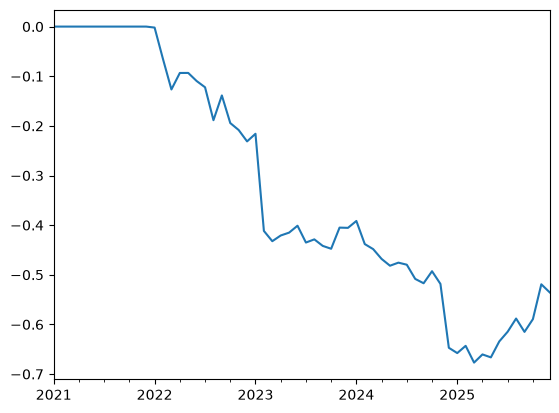

In [9]:
(
    ret,
    w,
    port_contrib_ret,
    gross_ret,
    net_ret,
) = calc_umd(px_monthly)
net_ret.cumsum().plot()

### UMD Analysis

It doesn't seem UMD is great for crypto.

I will try DMU, though since it seems this almost has a nice shape just
in the wrong direction.

### Trying out DMU (Down Minus Up)

Keep everything else the same except, use reversals instead of momentum
for this strategy with crypto.

In [10]:
def calc_dmu(px: pd.DataFrame, tcost_bps=20):
    # Calc returns from price
    ret = ReturnFrame.validate(px.copy(deep=True).pct_change(fill_method=None))

    # Calc weights
    w = ret.shift(periods=1).rolling(11).mean()
    w = w.rank(axis=1)
    w = w.subtract(w.mean(axis=1), axis=0)
    w = w.divide(w.abs().sum(axis=1), axis=0)
    w = -1*w
    w = PriceNeutralWeightFrame.validate(w)

    # Calc port contrib return
    port_contrib_ret = (w.shift() * ret)

    gross_ret = port_contrib_ret.sum(axis=1)
    to = (
        w.fillna(0) - w.shift().fillna(0)
    ).abs().sum(axis=1)
    net_ret = gross_ret - to * tcost_bps * 1e-4
    return (
        ret,
        w,
        port_contrib_ret,
        gross_ret,
        net_ret,
    )

<Axes: >

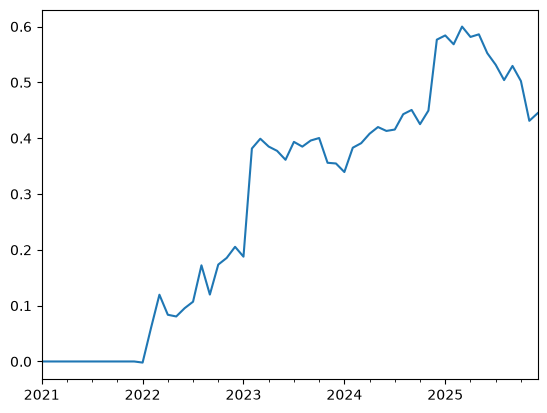

In [11]:
(
    ret,
    w,
    port_contrib_ret,
    gross_ret,
    net_ret,
) = calc_dmu(px_monthly)
net_ret.cumsum().plot()

### DMU Analysis

This does seem more promising.  I wonder if crypto typically is more
prone to reversals or something like this?

### Trying out DMU with changes to some outliers

I wonder what happens if I leave out varying percentiles of data.  Is
it possible for DMU to work better?

In [12]:
def _keep_one_side_outliers(
    signal: pd.DataFrame,
    outlier_pct: float,
    side: str,
) -> pd.DataFrame:
    pct_rank = signal.rank(axis=1, pct=True)
    if side == 'lower':
        is_outlier = pct_rank <= outlier_pct
    else:
        is_outlier = pct_rank >= 1 - outlier_pct
    return signal.where(is_outlier)


def calc_dmu_one_side_outliers_only(
    px: pd.DataFrame,
    tcost_bps: int = 20,
    outlier_pct: float = 0.2,
    side: str = 'lower',
) -> tuple:
    ret = px.copy(deep=True).pct_change(fill_method=None)

    signal = ret.shift(periods=1).rolling(11).mean()
    signal = _keep_one_side_outliers(signal, outlier_pct, side)

    w = signal.rank(axis=1)
    w = w.subtract(w.mean(axis=1), axis=0)
    w = w.divide(w.abs().sum(axis=1), axis=0)
    w = -1 * w
    w = PriceNeutralWeightFrame.validate(w)

    port_contrib_ret = w.shift() * ret

    gross_ret = port_contrib_ret.sum(axis=1)
    to = (w.fillna(0) - w.shift().fillna(0)).abs().sum(axis=1)
    net_ret = gross_ret - to * tcost_bps * 1e-4

    return ret, w, port_contrib_ret, gross_ret, net_ret

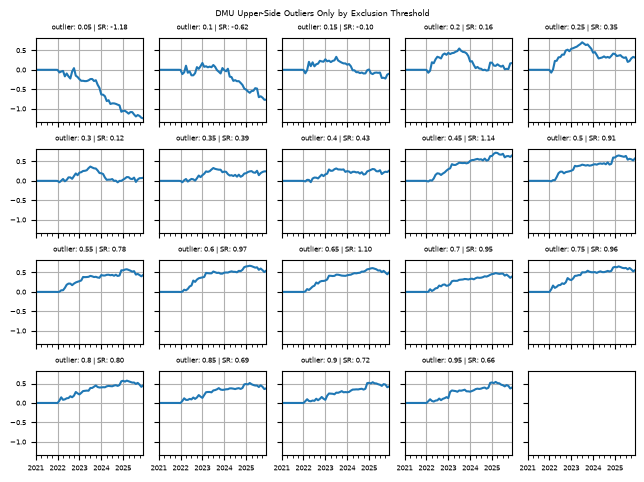

In [13]:
outlier_pcts = [outlier_thresh / 100 for outlier_thresh in range(5, 100, 5)] 

n_cols = 5
n_rows = math.ceil(len(outlier_pcts) / n_cols)

with plt.rc_context({"font.size": 5}):
    fig, ax = plt.subplots(n_rows, n_cols, sharex=True, sharey=True)
    fig.set_tight_layout(tight=True)
    fig.suptitle("DMU Upper-Side Outliers Only by Exclusion Threshold")
    
    axes = ax.flatten()

    for i, outlier_pct in enumerate(outlier_pcts):
        (
            ret, w, port_contrib_ret, gross_ret, net_ret,
        ) = calc_dmu_one_side_outliers_only(px_monthly, outlier_pct=outlier_pct, side='upper')
        sharpe = (net_ret.mean() / net_ret.std()) * np.sqrt(12)
        axes[i].set_title(f'outlier: {outlier_pct} | SR: {sharpe:.2f}', fontsize=5)
        net_ret.cumsum().plot(ax=axes[i])
        axes[i].grid()
    plt.show()

### DMU Leaving Out Percentiles Analysis

So, it seems that by leaving the values above the percentile threshold,
it's possible to get a positive return/Sharpe Ratio and even get a
Sharpe Ratio of above 1 in a few scenarios.  I am not complete sure this
is a robust signal, but it doesn't seem to change randomly across the
different thresholds, which makes me think there is somehting valuable
here for future analysis.

### More alternatives to try to further improve performance

Below, I will try out some more variations to see if I am able to better
isolate signal that can create robust strategies.

In [14]:
def calc_dmu_outliers_only(px: pd.DataFrame, tcost_bps=20, outlier_pct=0.2):
    def _keep_outliers(signal: pd.DataFrame, outlier_pct: float) -> pd.DataFrame:
        pct_rank = signal.rank(axis=1, pct=True)
        is_outlier = (pct_rank <= outlier_pct) | (pct_rank >= 1 - outlier_pct)
        return signal.where(is_outlier)  # NaN for middle stocks

    ret = px.copy(deep=True).pct_change(fill_method=None)

    signal = ret.shift(periods=1).rolling(11).mean()
    signal = _keep_outliers(signal, outlier_pct)

    w = signal.rank(axis=1)
    w = w.subtract(w.mean(axis=1), axis=0)
    w = w.divide(w.abs().sum(axis=1), axis=0)
    w = -1*w

    port_contrib_ret = w.shift() * ret

    gross_ret = port_contrib_ret.sum(axis=1)
    to = (w.fillna(0) - w.shift().fillna(0)).abs().sum(axis=1)
    net_ret = gross_ret - to * tcost_bps * 1e-4

    return (
        ret, 
        w, 
        port_contrib_ret, 
        gross_ret, 
        net_ret,
    )

In [15]:
# NOTE: this is just example -- in future use like volume or something
tmp = px[px.index == datetime(2022, 1, 1)].dropna(axis=1).rank(axis=1).T
tmp = tmp.sort_values(by=tmp.columns[0], ascending=False)
top_half_coins_by_2022_start_price = tmp.index.to_numpy()[:len(tmp.index)//2]
bottom_half_coins_by_2022_start_price = tmp.index.to_numpy()[len(tmp.index)//2:]


/var/folders/wj/fv2_zwx12dl4_42g6193kl780000gn/T/ipykernel_73640/3131058120.py:17: RuntimeWarning: invalid value encountered in scalar divide
  sharpe = (net_ret.mean() / net_ret.std()) * np.sqrt(12)


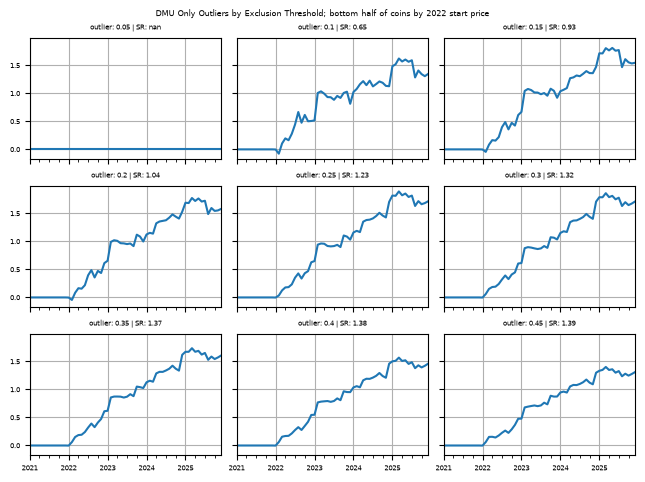

In [16]:
outlier_pcts = [outlier_thresh / 100 for outlier_thresh in range(5, 50, 5)] 

n_cols = 3
n_rows = math.ceil(len(outlier_pcts) / n_cols)

with plt.rc_context({"font.size": 5}):
    fig, ax = plt.subplots(n_rows, n_cols, sharex=True, sharey=True)
    fig.set_tight_layout(tight=True)
    fig.suptitle("DMU Only Outliers by Exclusion Threshold; bottom half of coins by 2022 start price")
    
    axes = ax.flatten()

    for i, outlier_pct in enumerate(outlier_pcts):
        (
            ret, w, port_contrib_ret, gross_ret, net_ret,
        ) = calc_dmu_outliers_only(px_monthly[bottom_half_coins_by_2022_start_price], outlier_pct=outlier_pct)
        sharpe = (net_ret.mean() / net_ret.std()) * np.sqrt(12)
        axes[i].set_title(f'outlier: {outlier_pct} | SR: {sharpe:.2f}', fontsize=5)
        net_ret.cumsum().plot(ax=axes[i])
        axes[i].grid()
    plt.show()

#### Graph analysis

It's very intersting that performing this DMU strategy on coins with
coin prices lower prices at the start of 2022 can lead to higher
Sharpe Ratios of 1.3+.  This me wonder if looking at things such as
trade volume or coin price on an ongoing basis can help to create
strategies with higher Sharpe Ratios.

#### Try out DMU Outliers Only based on lower half Px Coins 12 month MA

In [17]:
def calc_dmu_outliers_only_lower_half_price(px: pd.DataFrame, tcost_bps=20, outlier_pct=0.2):
    
    ret = px.copy(deep=True).pct_change(fill_method=None)

    # Get lower half of coins based on px on ongoing basis
    px_signal = px.rolling(12).mean()
    px_pct_rank = px_signal.rank(axis=1, pct=True)
    is_lower_half_px_coin_index = px_pct_rank < 0.5


    # Calculate umd/dmu ma signal
    signal = ret.shift(periods=1).rolling(11).mean()

    # Climinate coins in upper half of px at every index
    signal = signal.where(is_lower_half_px_coin_index)

    pct_rank = signal.rank(axis=1, pct=True)
    is_outlier = (pct_rank <= outlier_pct) | (pct_rank >= 1 - outlier_pct)
    signal = signal.where(is_outlier)

    w = signal.rank(axis=1)
    w = w.subtract(w.mean(axis=1), axis=0)
    w = w.divide(w.abs().sum(axis=1), axis=0)
    w = -1*w

    port_contrib_ret = w.shift() * ret

    gross_ret = port_contrib_ret.sum(axis=1)
    to = (w.fillna(0) - w.shift().fillna(0)).abs().sum(axis=1)
    net_ret = gross_ret - to * tcost_bps * 1e-4
    return (
        ret, 
        w, 
        port_contrib_ret, 
        gross_ret, 
        net_ret,
    )

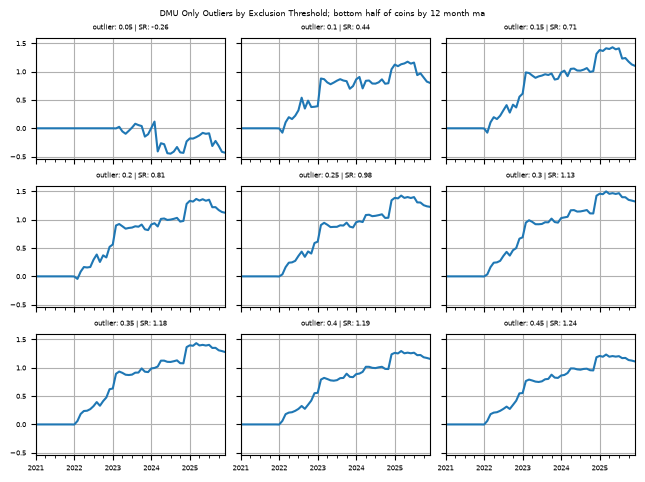

In [18]:
outlier_pcts = [outlier_thresh / 100 for outlier_thresh in range(5, 50, 5)] 

n_cols = 3
n_rows = math.ceil(len(outlier_pcts) / n_cols)

with plt.rc_context({"font.size": 5}):
    fig, ax = plt.subplots(n_rows, n_cols, sharex=True, sharey=True)
    fig.set_tight_layout(tight=True)
    fig.suptitle("DMU Only Outliers by Exclusion Threshold; bottom half of coins by 12 month ma")
    
    axes = ax.flatten()

    for i, outlier_pct in enumerate(outlier_pcts):
        (
            ret, w, port_contrib_ret, gross_ret, net_ret,
        ) = calc_dmu_outliers_only_lower_half_price(px_monthly, outlier_pct=outlier_pct)
        sharpe = (net_ret.mean() / net_ret.std()) * np.sqrt(12)
        axes[i].set_title(f'outlier: {outlier_pct} | SR: {sharpe:.2f}', fontsize=5)
        net_ret.cumsum().plot(ax=axes[i])
        axes[i].grid()
    plt.show()

#### Graph Analysis

This seems to show promis as well.  I really like that each increase in
"outlier" threshold seems to improve signal.  Though the overall Sharpe
Ratio is lower than in the `DMU Only Outliers by Exclusion Threshold; bottom half of coins by 2022 start price`
graph, I feel optimistic that this approach can be further honed or
tuned as I feel more confident that there is no look ahead bias and
start can be robust to universe changes with this ongoing calculation
of average coin price.

## Trying Out Altering Multiple Parameters

Below I will try out varying a few different parameters at the same time
and see if I am able to figure out a good way to do this and if the
dmu outliers only strategy can be improved by altering some easy to
change parameters such as the lower nth percentile threshold, "outlier"
threshold, or moving average timeframe.

In [ ]:
def calc_dmu_outliers_only_lower_nth_percentile_price(
        px: pd.DataFrame,
        lower_nth_price_threshold=0.5,
        outlier_pct=0.2,
        tcost_bps=20, 
    ):
    
    ret = px.copy(deep=True).pct_change(fill_method=None)

    # Get lower half of coins based on px on ongoing basis
    px_signal = px.rolling(12).mean()
    px_pct_rank = px_signal.rank(axis=1, pct=True)
    is_lower_half_px_coin_index = px_pct_rank < lower_nth_price_threshold


    # Calculate umd/dmu ma signal
    signal = ret.shift(periods=1).rolling(11).mean()

    # Climinate coins in upper half of px at every index
    signal = signal.where(is_lower_half_px_coin_index)

    pct_rank = signal.rank(axis=1, pct=True)
    is_outlier = (pct_rank <= outlier_pct) | (pct_rank >= 1 - outlier_pct)
    signal = signal.where(is_outlier)

    w = signal.rank(axis=1)
    w = w.subtract(w.mean(axis=1), axis=0)
    w = w.divide(w.abs().sum(axis=1), axis=0)
    w = -1*w

    port_contrib_ret = w.shift() * ret

    gross_ret = port_contrib_ret.sum(axis=1)
    to = (w.fillna(0) - w.shift().fillna(0)).abs().sum(axis=1)
    net_ret = gross_ret - to * tcost_bps * 1e-4
    return (
        ret, 
        w, 
        port_contrib_ret, 
        gross_ret, 
        net_ret,
    )

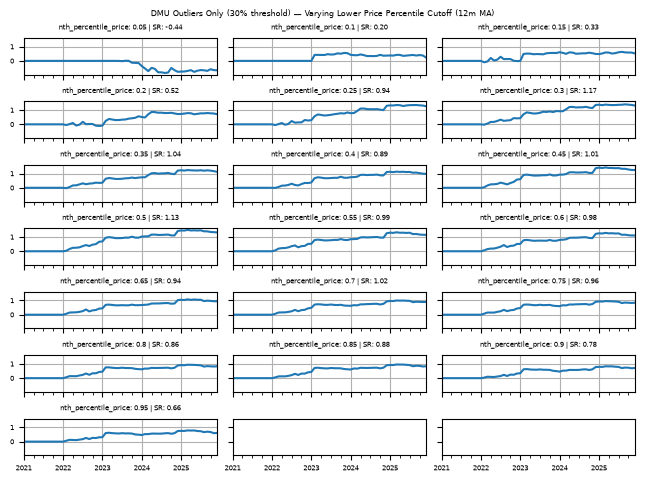

In [37]:
nth_percentile_prices = [nth_percentile_price / 100 for nth_percentile_price in range(5, 100, 5)] 

n_cols = 3
n_rows = math.ceil(len(nth_percentile_prices) / n_cols)

with plt.rc_context({"font.size": 5}):
    fig, ax = plt.subplots(n_rows, n_cols, sharex=True, sharey=True)
    fig.set_tight_layout(tight=True)
    fig.suptitle("DMU Outliers Only (30% threshold) — Varying Lower Price Percentile Cutoff (12m MA)")
    
    axes = ax.flatten()

    for i, nth_percentile_price in enumerate(nth_percentile_prices):
        (
            ret, w, port_contrib_ret, gross_ret, net_ret,
        ) = calc_dmu_outliers_only_lower_nth_percentile_price(
            px_monthly, 
            outlier_pct=0.3,
            lower_nth_price_threshold=nth_percentile_price,
        )
        sharpe = (net_ret.mean() / net_ret.std()) * np.sqrt(12)
        axes[i].set_title(f'nth_percentile_price: {nth_percentile_price} | SR: {sharpe:.2f}', fontsize=5)
        net_ret.cumsum().plot(ax=axes[i])
        axes[i].grid()
    plt.show()

In [38]:
def calc_dmu_outliers_only_lower_half_price_n_month_ma(
        px: pd.DataFrame,
        n_month_ma=12,
        outlier_pct=0.2,
        tcost_bps=20, 
    ):
    
    ret = px.copy(deep=True).pct_change(fill_method=None)

    # Get lower half of coins based on px on ongoing basis
    px_signal = px.rolling(n_month_ma).mean()
    px_pct_rank = px_signal.rank(axis=1, pct=True)
    is_lower_half_px_coin_index = px_pct_rank < 0.5


    # Calculate umd/dmu ma signal
    signal = ret.shift(periods=1).rolling(n_month_ma-1).mean()

    # Climinate coins in upper half of px at every index
    signal = signal.where(is_lower_half_px_coin_index)

    pct_rank = signal.rank(axis=1, pct=True)
    is_outlier = (pct_rank <= outlier_pct) | (pct_rank >= 1 - outlier_pct)
    signal = signal.where(is_outlier)

    w = signal.rank(axis=1)
    w = w.subtract(w.mean(axis=1), axis=0)
    w = w.divide(w.abs().sum(axis=1), axis=0)
    w = -1*w

    port_contrib_ret = w.shift() * ret

    gross_ret = port_contrib_ret.sum(axis=1)
    to = (w.fillna(0) - w.shift().fillna(0)).abs().sum(axis=1)
    net_ret = gross_ret - to * tcost_bps * 1e-4
    return (
        ret, 
        w, 
        port_contrib_ret, 
        gross_ret, 
        net_ret,
    )

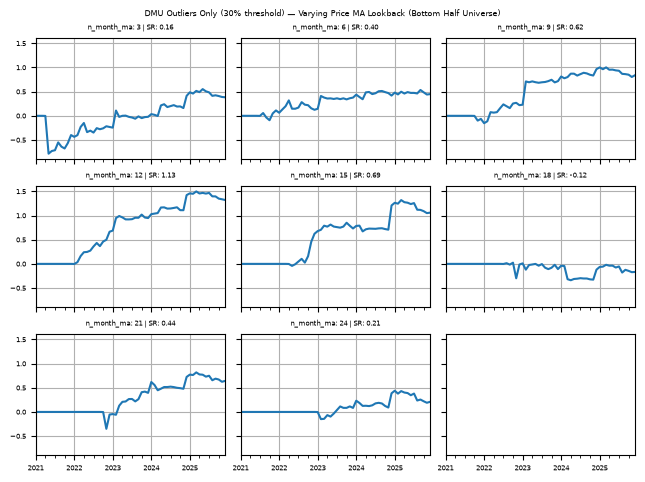

In [39]:
n_month_mas = [n_month_ma for n_month_ma in range(3, 25, 3)] 

n_cols = 3
n_rows = math.ceil(len(n_month_mas) / n_cols)

with plt.rc_context({"font.size": 5}):
    fig, ax = plt.subplots(n_rows, n_cols, sharex=True, sharey=True)
    fig.set_tight_layout(tight=True)
    fig.suptitle("DMU Outliers Only (30% threshold) — Varying Price MA Lookback (Bottom Half Universe)")
    
    axes = ax.flatten()

    for i, n_month_ma in enumerate(n_month_mas):
        (
            ret, w, port_contrib_ret, gross_ret, net_ret,
        ) = calc_dmu_outliers_only_lower_half_price_n_month_ma(
            px_monthly, 
            outlier_pct=0.3,
            n_month_ma=n_month_ma,
        )
        sharpe = (net_ret.mean() / net_ret.std()) * np.sqrt(12)
        axes[i].set_title(f'n_month_ma: {n_month_ma} | SR: {sharpe:.2f}', fontsize=5)
        net_ret.cumsum().plot(ax=axes[i])
        axes[i].grid()
    plt.show()

#### Graph analyses

The above 2 graphs seem to show that it is not obvious how to improve
this strategy by changing a few parameters as it seems like 1.2 is
about the upper limit.  I will try a more holistic grid search that
outputs into a table below.

In [40]:
def calc_dmu_only_outliers_variables(
        px: pd.DataFrame,
        n_month_ma=12,
        px_pct_rank_threshold=0.5,
        outlier_pct=0.2,
        tcost_bps=20, 
    ):
    
    ret = px.copy(deep=True).pct_change(fill_method=None)

    # Get lower half of coins based on px on ongoing basis
    px_signal = px.rolling(n_month_ma).mean()
    px_pct_rank = px_signal.rank(axis=1, pct=True)
    is_lower_half_px_coin_index = px_pct_rank < px_pct_rank_threshold


    # Calculate umd/dmu ma signal
    signal = ret.shift(periods=1).rolling(n_month_ma-1).mean()

    # Eliminate coins in upper half of px at every index
    signal = signal.where(is_lower_half_px_coin_index)

    pct_rank = signal.rank(axis=1, pct=True)
    is_outlier = (pct_rank <= outlier_pct) | (pct_rank >= 1 - outlier_pct)
    signal = signal.where(is_outlier)

    w = signal.rank(axis=1)
    w = w.subtract(w.mean(axis=1), axis=0)
    w = w.divide(w.abs().sum(axis=1), axis=0)
    w = -1*w

    port_contrib_ret = w.shift() * ret

    gross_ret = port_contrib_ret.sum(axis=1)
    to = (w.fillna(0) - w.shift().fillna(0)).abs().sum(axis=1)
    net_ret = gross_ret - to * tcost_bps * 1e-4
    return (
        ret, 
        w, 
        port_contrib_ret, 
        gross_ret, 
        net_ret,
    )

In [49]:
from itertools import product

nth_percentile_prices = [nth_percentile_price / 100 for nth_percentile_price in range(5, 100, 5)] 
outlier_pcts = [outlier_thresh / 100 for outlier_thresh in range(5, 50, 5)]
n_month_mas = [n_month_ma for n_month_ma in range(3, 25, 3)]

records = []
for px_pct_rank_threshold, outlier_pct, n_month_ma in product(nth_percentile_prices, outlier_pcts, n_month_mas):
    _, _, _, _, net_ret = calc_dmu_only_outliers_variables(
        px_monthly,
        n_month_ma=n_month_ma,
        px_pct_rank_threshold=px_pct_rank_threshold,
        outlier_pct=outlier_pct,
    )
    std = net_ret.std()
    sharpe = (net_ret.mean() / std) * np.sqrt(12) if std > 0 else np.nan
    records.append({
        'px_pct_rank_threshold': px_pct_rank_threshold,
        'outlier_pct':           outlier_pct,
        'n_month_ma':            n_month_ma,
        'sharpe':                round(sharpe, 3) if not np.isnan(sharpe) else np.nan,
    })

# Pivot: rows = (px_pct_rank_threshold, outlier_pct), columns = n_month_ma, values = sharpe
results = (
    pd.DataFrame(records)
    .set_index(['px_pct_rank_threshold', 'outlier_pct', 'n_month_ma'])['sharpe']
    .unstack('n_month_ma')
)
results.index.names = ['price_pct_threshold', 'outlier_pct']
results.columns.name = 'n_month_ma'

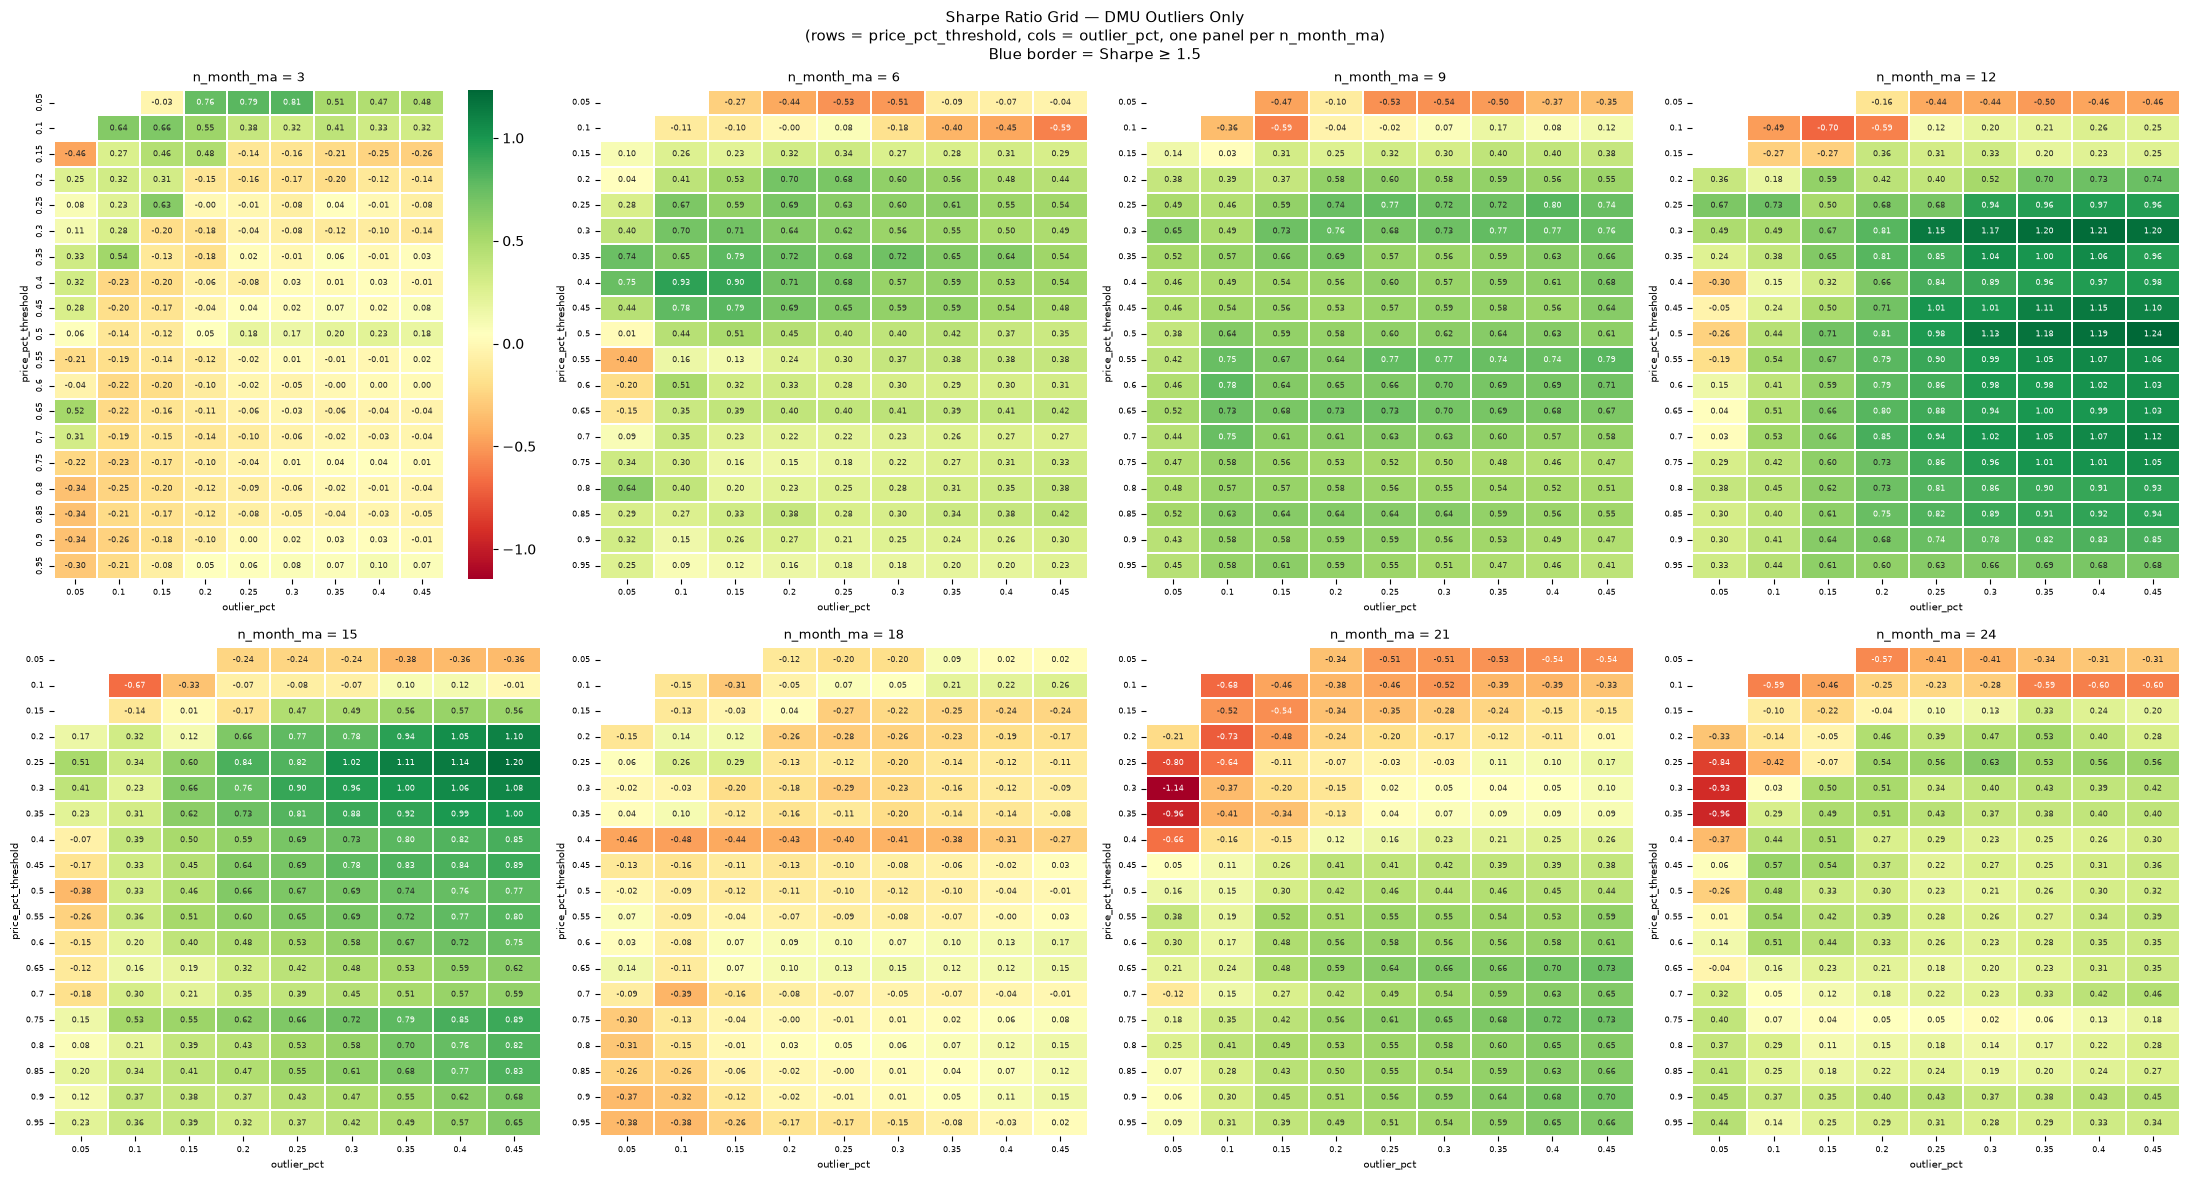

In [50]:
import seaborn as sns

highlight_threshold = 1.5  # blue border on cells at or above this Sharpe

n_heatmap_cols = 4
n_heatmap_rows = math.ceil(len(n_month_mas) / n_heatmap_cols)

fig, axes = plt.subplots(
    n_heatmap_rows, n_heatmap_cols,
    figsize=(22, n_heatmap_rows * 6),
)
fig.suptitle(
    "Sharpe Ratio Grid — DMU Outliers Only\n"
    "(rows = price_pct_threshold, cols = outlier_pct, one panel per n_month_ma)\n"
    f"Blue border = Sharpe ≥ {highlight_threshold}",
    fontsize=11,
)
fig.set_tight_layout(tight=True)

vmin = float(results.min().min())
vmax = float(results.max().max())

for i, n_month_ma in enumerate(n_month_mas):
    ax = axes.flatten()[i]

    # 2D slice: price_pct_threshold (rows) × outlier_pct (cols)
    data = results[n_month_ma].unstack('outlier_pct')

    sns.heatmap(
        data,
        ax=ax,
        cmap='RdYlGn',
        vmin=vmin,
        vmax=vmax,
        annot=True,
        fmt='.2f',
        annot_kws={'size': 6},
        linewidths=0.3,
        cbar=i == 0,  # only show colorbar on first panel
    )

    # Highlight cells that meet the threshold with a blue border
    for row_idx in range(data.shape[0]):
        for col_idx in range(data.shape[1]):
            val = data.iloc[row_idx, col_idx]
            if not np.isnan(val) and val >= highlight_threshold:
                ax.add_patch(plt.Rectangle(
                    (col_idx, row_idx), 1, 1,
                    fill=False, edgecolor='blue', linewidth=2, clip_on=False,
                ))

    ax.set_title(f'n_month_ma = {n_month_ma}', fontsize=9)
    ax.set_xlabel('outlier_pct', fontsize=7)
    ax.set_ylabel('price_pct_threshold', fontsize=7)
    ax.tick_params(labelsize=6)

plt.show()

### Heat map analysis

It seems that the upper limit for this strategy appears to be 1.2.

I think this sort of grid search approach, could be good for future
analysis as well.  Think may want to use volume or other metrics to 
further improve DMU.

Though I think this approach could also be good for other strategies
as well.